In [1]:
import pandas as pd
from glob import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import json
from pathlib import Path
import rasterio as rio
import rasterio.warp
from tqdm import tqdm
import geopandas as gpd
import numpy as np
from kneed import KneeLocator
from socket import gethostname
import seaborn as sns

host = gethostname()

if host == 'gcer-a100':
    font_path = '/home/dhester/.fonts/InterVariable.ttf'
elif host == 'ABE-BC546S3':
    font_path = r"C:\Users\dh2306\AppData\Local\Microsoft\Windows\Fonts\Inter-VariableFont_opsz,wght.ttf"
elif host == 'MacBookPro':
    font_path = '/Users/dak/Library/Fonts/Inter-VariableFont_opsz,wght.ttf'
else:
    raise NotImplementedError("Unknown host. Please set the Inter font path for this machine.")

font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

# plt.style.use('bmh')
plt.style.use('seaborn-v0_8-colorblind')
# plt.style.use('fivethirtyeight')
# set grid background color to white
# plt.rcParams['axes.facecolor'] = 'white'
# use outline around axes for better visibility when multiple axes are present
# plt.rcParams['axes.edgecolor'] = 'black'
# plt.rcParams['axes.linewidth'] = 0.5


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()

In [41]:
"""
Tiles

11TNJ (Nampa, ID; EPSG:32611 UTM 11N)
540383.1,4840460.9

12SUC (Peoria, AZ; EPSG:32612 UTM 12N)
382858.7,3728723.4

14RPU (Austin, TX; EPSG:32614 UTM 14N)
623298.9,3336168.4

16SEF (Nashville, TN; EPSG:32614 UTM 16N)
1601415.2,4071439.4
"""


tiles = [
    {
        'mgrs': '11TNJ',
        # 'location': 'Nampa, ID',
        'location': 'Boise, ID',
        'epsg': 32611,
        'utm_zone': '11N',
        # 'center_coords': (540383.1, 4840460.9)
        'center_coords': (551142.1, 4821385.4)
    },
    {
        'mgrs': '12SUC',
        # 'location': 'Peoria, AZ',
        'location': 'Phoenix, AZ',
        'epsg': 32612,
        'utm_zone': '12N',
        # 'center_coords': (382858.7, 3728723.4)
        'center_coords': (388223.8, 3714409.7)
    },
    {
        'mgrs': '14RPU',
        'location': 'Austin, TX',
        'epsg': 32614,
        'utm_zone': '14N',
        # 'center_coords': (623298.9, 3336168.4)
        'center_coords': (623271.1, 3335524.8)
    },
    {
        'mgrs': '16SEF',
        'location': 'Nashville, TN',
        'epsg': 32616,
        'utm_zone': '16N',
        'center_coords': (542162.6, 4020536.4)
    }
]

years = [2016, 2018, 2020, 2022, 2024]

og_dir = Path(r'Z:\dbcenter\products\land\temporalcomposites\S2L2A_hotspots_dakota')
out_dir = Path(r'Z:\public\s2flow_outputs\s2_out_hotspots')

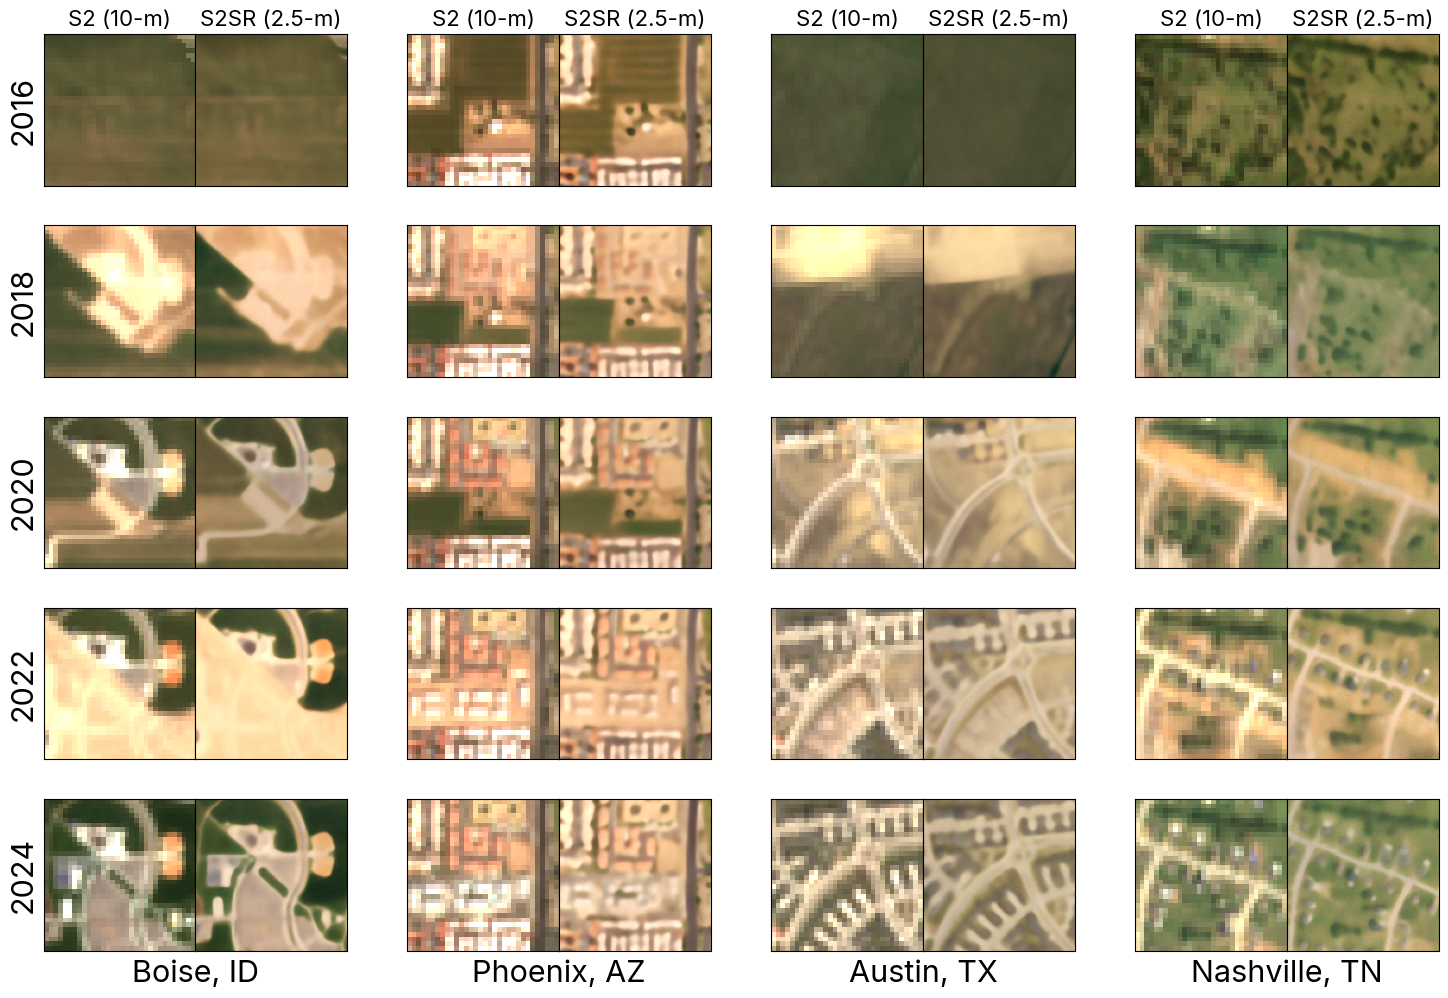

In [51]:
tile_size = 32 # size of raster

instet_padding = 0.00 # percentage of tile size to use as padding for inset axes

divisors = [2500, 2500, 2500, 1500]

fig, ax = plt.subplots(5, 4, figsize=(18, 12))
for j, tile in enumerate(tiles):
    for i, year in enumerate(years):
        
        # create 2 axes inste (2 rows, 1 column
        # top_inset = ax[i, j].inset_axes([0, 0.5+instet_padding, 1, 0.5-instet_padding]) 
        # bottom_inset = ax[i, j].inset_axes([0, 0, 1, 0.5-instet_padding])
        
        top_inset = ax[i, j].inset_axes([0, 0, 0.5, 1])
        bottom_inset = ax[i, j].inset_axes([0.5, 0, 0.5, 1])
        
        top_inset.set_xticks([])
        top_inset.set_yticks([])
        bottom_inset.set_xticks([])
        bottom_inset.set_yticks([])
        
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove axes spines for cleaner look when multiple axes are present
        ax[i, j].spines[:].set_visible(False)
        
        # top inset - plot original resolution composite
        composite_path = og_dir / str(year) / 'annual' / tile['mgrs'] / f"{year}0101_{year}1231" / 's2_composite_mean.tif'
        with rio.open(composite_path) as src:
            
            # convert coords to pixel coordinates
            row, col = src.index(tile['center_coords'][0], tile['center_coords'][1])
            
            # sanitize window to ensure it doesn't go out of bounds
            left = max(col - tile_size // 2, 0)
            top = max(row - tile_size // 2, 0)
            width = min(tile_size, src.width - left)
            height = min(tile_size, src.height - top)
            
            window = rio.windows.Window(left, top, tile_size, tile_size)
            composite_data = src.read((3, 2, 1), window=window)
            
            composite_data = np.transpose(composite_data, (1, 2, 0)) # convert from (bands, height, width) to (height, width, bands)
            
            composite_data = composite_data.clip(0, divisors[j]) / divisors[j] # clip and normalize for better visualization
        
        top_inset.imshow(composite_data)
        
        # now show the super-resolved result in the bottom inset
        sr_path = out_dir / str(year) / (tile['mgrs'] + ".tif")
        sr_tile_size = tile_size * 4 # super-resolved tiles are 4x the resolution of the original composites
        with rio.open(sr_path) as src:
            row, col = src.index(tile['center_coords'][0], tile['center_coords'][1])
            
            left = max(col - sr_tile_size // 2, 0)
            top = max(row - sr_tile_size // 2, 0)
            width = min(sr_tile_size, src.width - left)
            height = min(sr_tile_size, src.height - top)
            
            window = rio.windows.Window(left, top, sr_tile_size, sr_tile_size)
            sr_data = src.read((1, 2, 3), window=window)
            sr_data = np.transpose(sr_data, (1, 2, 0))
            sr_data = sr_data.clip(0, divisors[j]) / divisors[j]
        
        bottom_inset.imshow(sr_data)
        
        if j == 0:
            ax[i, j].set_ylabel(str(year), fontsize=22)
        if i == 0:
            top_inset.set_title('S2 (10-m)', fontsize=16)
            bottom_inset.set_title('S2SR (2.5-m)', fontsize=16)
        elif i == len(years) - 1:
            ax[i, j].set_xlabel(tile['location'], fontsize=22)
            


out_dir = Path('../figures/temporal_changes')
out_dir.mkdir(exist_ok=True, parents=True)

for file_ext in ['png', 'pdf']:
    plt.savefig(out_dir / f'temporal_changes.{file_ext}', bbox_inches='tight', dpi=300)
# ax[0, 0].set_title('2016', fontsize=12)
# ax[0, 1].set_title('2018', fontsize=12)
# ax[0, 2].set_title('2020', fontsize=12)
# ax[0, 3].set_title('2022', fontsize=12)
# ax[0, 4].set_title('2024', fontsize=12)

# fig.tight_layout()